# Import necessary libraries

In [53]:
import pandas as pd
#matplotlib and seaborn are used for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

Reading Dataset

In [54]:
df = pd.read_csv("weight-height.csv")

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  str    
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), str(1)
memory usage: 234.5 KB


In [56]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [57]:
df["Height"].min()

np.float64(54.2631333250971)

In [58]:
df["Height"].max()

np.float64(78.9987423463896)

In [59]:
df["Height"].mean()

np.float64(66.36755975482124)

In [60]:
df["Height"].median()

np.float64(66.31807008178464)

In [61]:
df["Height"].quantile(0.5)

np.float64(66.31807008178464)

In [62]:
df['Height'].std()

np.float64(3.847528120773229)

Data Visualization

In [63]:
# !pip install matplotlib
# !pip install seaborn

Histogram plot

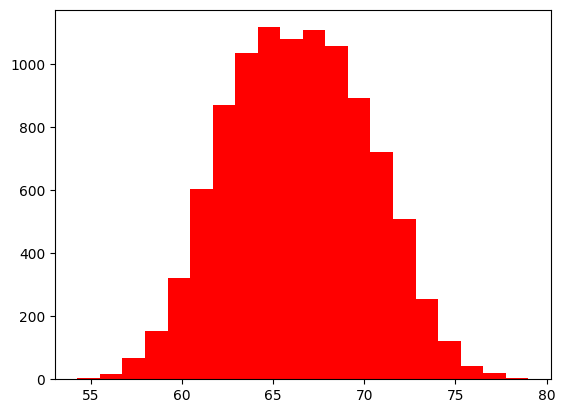

In [64]:
import warnings
warnings.filterwarnings("ignore") # to ignore warnings
plt.hist(df['Height'], bins = 20, color = "red")
plt.show() # --- IGNORE ---

<Axes: xlabel='Height', ylabel='Count'>

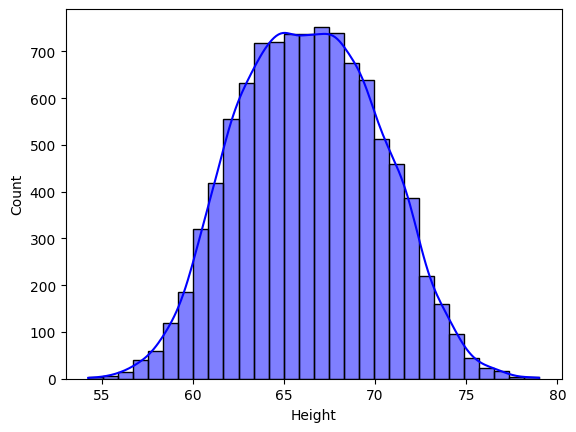

In [65]:
sns.histplot(df['Height'], bins = 30, color = "blue", kde=True)# kde= kernel density estimation

<Axes: xlabel='Weight', ylabel='Count'>

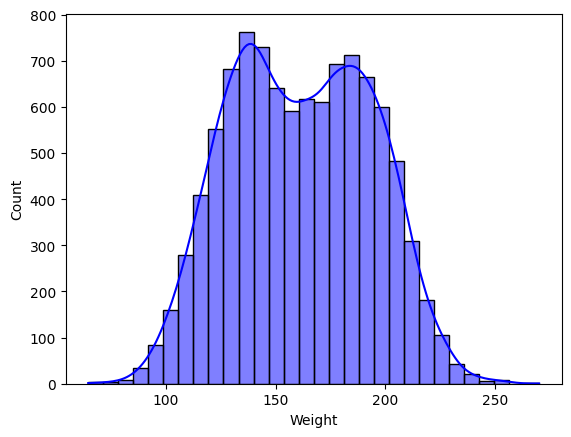

In [66]:
sns.histplot(df['Weight'], bins = 30, color = "blue", kde=True)# kde= kernel density estimation

In [67]:
h_std = df['Height'].std()
h_std

np.float64(3.847528120773229)

In [68]:
h_mean = df["Height"].mean()
h_mean

np.float64(66.36755975482124)

In [69]:
max_value = h_mean + 3*h_std
min_value = h_mean - 3*h_std

In [70]:
max_value

np.float64(77.91014411714093)

In [71]:
min_value

np.float64(54.82497539250156)

In [72]:
df[df["Height"] > max_value]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783


In [73]:
df[df["Height"] < min_value]

,Gender,Height,Weight
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [74]:
# showing outlaiers
df[(df["Height"] > max_value) | (df["Height"] < min_value)]

,Gender,Height,Weight
994,Male,78.095867,255.690835
1317,Male,78.462053,227.342565
2014,Male,78.998742,269.989699
3285,Male,78.528210,253.889004
3757,Male,78.621374,245.733783
6624,Female,54.616858,71.393749
9285,Female,54.263133,64.700127


In [75]:
# showing valid data
df[(df["Height"] <= max_value) & (df["Height"] >= min_value)]

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [76]:
df1 = df[(df["Height"] <= max_value) & (df["Height"] >= min_value)]

In [77]:
df.shape, df1.shape

((10000, 3), (9993, 3))

<Axes: ylabel='Height'>

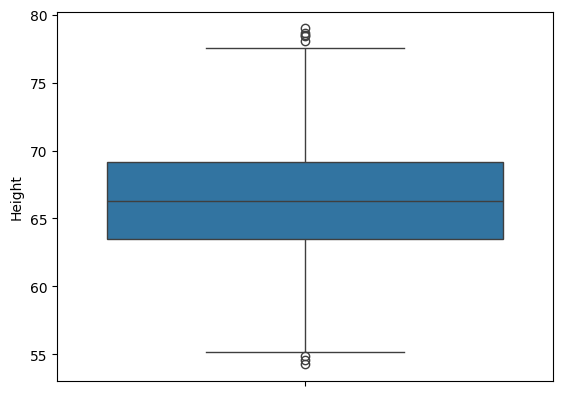

In [78]:
# boxplot
sns.boxplot(df["Height"])

<Axes: ylabel='Height'>

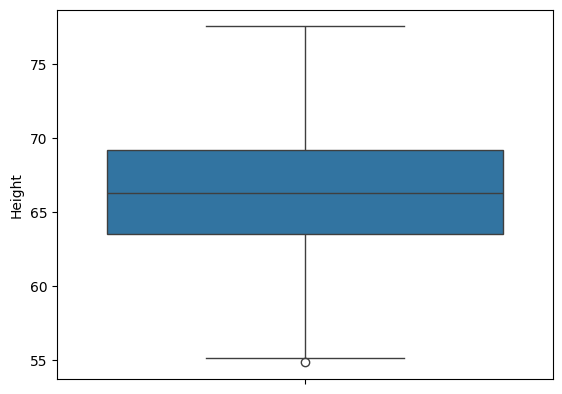

In [79]:
# boxplot after removing outliers
sns.boxplot(df1["Height"])

In [80]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [81]:
#z-score method
df['zscore'] = (df['Height'] - h_mean) / h_std
df.head()

,Gender,Height,Weight,zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375


In [82]:
df["zscore"].max()

np.float64(3.2829344439021027)

In [83]:
df["zscore"].min()

np.float64(-3.1460267604987755)

In [84]:
df[df["zscore"] >3]

,Gender,Height,Weight,zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854


In [85]:
df[df["zscore"] < -3]

,Gender,Height,Weight,zscore
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [86]:
# for removing
df[(df["zscore"] > 3) | (df["zscore"] < -3)]

,Gender,Height,Weight,zscore
994,Male,78.095867,255.690835,3.048271
1317,Male,78.462053,227.342565,3.143445
2014,Male,78.998742,269.989699,3.282934
3285,Male,78.528210,253.889004,3.160640
3757,Male,78.621374,245.733783,3.184854
6624,Female,54.616858,71.393749,-3.054091
9285,Female,54.263133,64.700127,-3.146027


In [87]:
# valid 
df2 = df[(df["zscore"] <= 3) | (df["zscore"] >= -3)]

In [88]:
df2

,Gender,Height,Weight,zscore
0,Male,73.847017,241.893563,1.943964
1,Male,68.781904,162.310473,0.627505
2,Male,74.110105,212.740856,2.012343
3,Male,71.730978,220.042470,1.393991
4,Male,69.881796,206.349801,0.913375
...,...,...,...,...
9995,Female,66.172652,136.777454,-0.050658
9996,Female,67.067155,170.867906,0.181830
9997,Female,63.867992,128.475319,-0.649655
9998,Female,69.034243,163.852461,0.693090


<Axes: ylabel='zscore'>

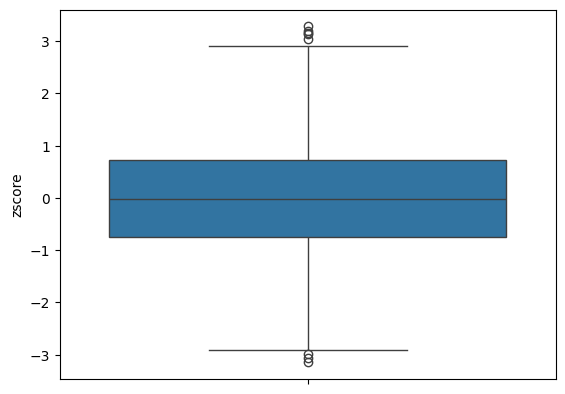

In [89]:
sns.boxplot(df2["zscore"])

In [90]:
q1 = df["Height"].quantile(0.25)
q3 = df["Height"].quantile(0.75)

iqr = q3 - q1
  
lower_whisker = q1 - 1.5*iqr
upper_whisker = q3 + 1.5*iqr

In [91]:
df3 = df[( df["Height"] <= upper_whisker) & (df["Height"] >= lower_whisker)]

<Axes: ylabel='Height'>

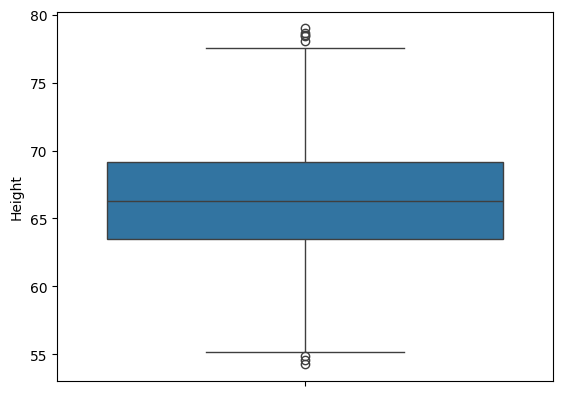

In [92]:
sns.boxplot(df["Height"])

In [94]:
def uotlier_remove(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  
  iqr = q3 - q1
  
  lower_whisker = q1 - 1.5*iqr
  upper_whisker = q3 + 1.5*iqr
  
  return df[( df[col] <= upper_whisker) & (df[col] >= lower_whisker)]

In [96]:
df = uotlier_remove(df, "Height")

datapiplining

Data Visualization

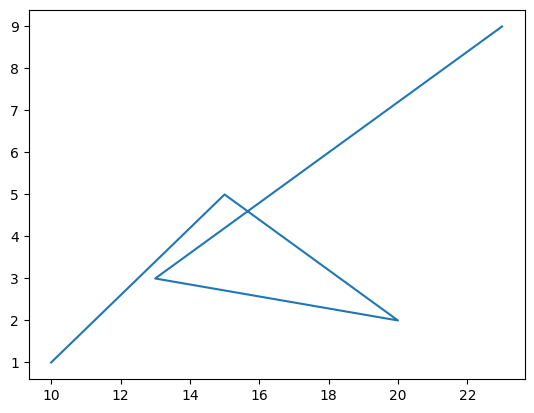

In [100]:
x = [10, 15, 20, 13, 23]
y =[1, 5, 2, 3, 9]

plt.plot(x, y) # to plot a line graph

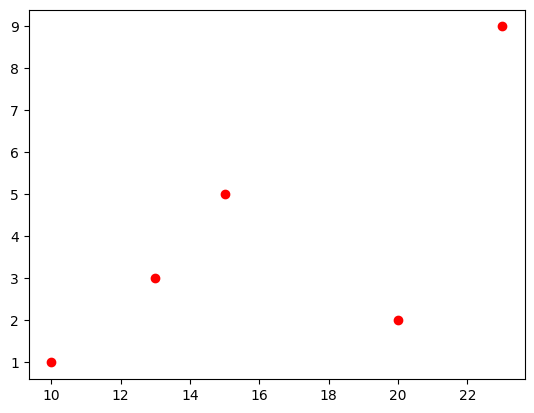

In [102]:
plt.plot(x, y, 'o', color = 'r', marker = 'o') 